In [36]:
# Importar librerías
import pandas as pd
import datetime as dt
import matplotlib.pyplot as plt

# Cargar archivo
df_log  = pd.read_table('../datasets/logs_exp_us.csv')

In [37]:
# Preparación de los datos
# Renombrar las columnas 
df_log.columns = ['eventname', 'device', 'event', 'group']

# Cambiar los tipos de datos
df_log['event'] = pd.to_datetime(df_log['event'], unit='s', utc=True, errors='coerce')
df_log['eventname'] = df_log['eventname'].astype('string')
df_log['device'] = df_log['device'].astype('string')

# Mapear los valores de los grupos
map_groups = {246:'A1', 247: 'A2', 248:'B'}
df_log['group'] = df_log['group'].map(map_groups).astype('string')

# Eliminar duplicados
df_log = df_log.dropna(subset=['device']).drop_duplicates(subset=['device', 'event', 'eventname', 'group'])

# Crear una columna que contenga solo la fecha
#df_log['date'] = df_log['event'].dt.floor('D')
df_log['date'] = df_log['event'].dt.date

In [38]:
# Cuántos eventos hay en los registros?
print(f"Total de eventos registrados: { df_log.shape[0]:,}")

Total de eventos registrados: 243,713


In [39]:
# ¿Cuántos eventos por tipo?
print(df_log['eventname']
      .value_counts(dropna=False)
      .rename_axis('eventname')
      .reset_index(name='events'))

                 eventname  events
0         MainScreenAppear  119101
1       OffersScreenAppear   46808
2         CartScreenAppear   42668
3  PaymentScreenSuccessful   34118
4                 Tutorial    1018


In [40]:
# ¿Cuántos usuarios hay en los registros? (Se considera cada device = usuario)
print(f"Usuarios únicos (total): {df_log['device'].dropna().nunique()}")

Usuarios únicos (total): 7551


In [41]:
# ¿Cuál es el promedio de eventos por usuario?
df_events_per_user = df_log.groupby('device', as_index=False).size().rename(columns={'size':'events'})
print(f"Cantidad promedio de eventos por usuario: {df_events_per_user['events'].mean():2f}")

Cantidad promedio de eventos por usuario: 32.275593


Rango: 2019-07-25 - 2019-08-07


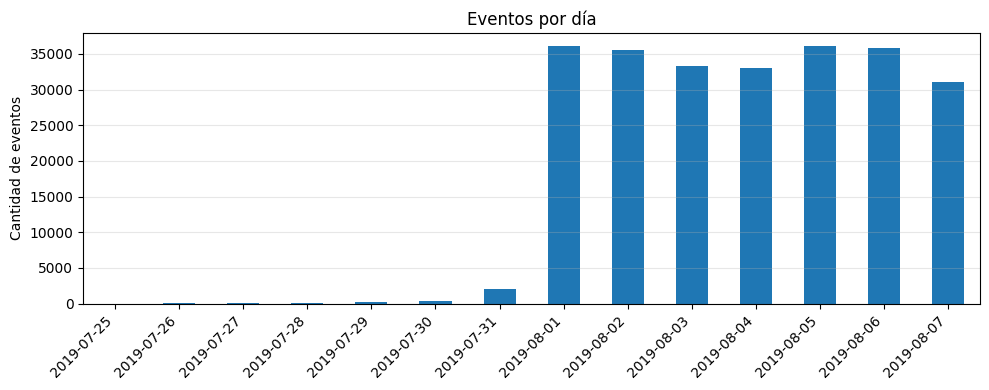

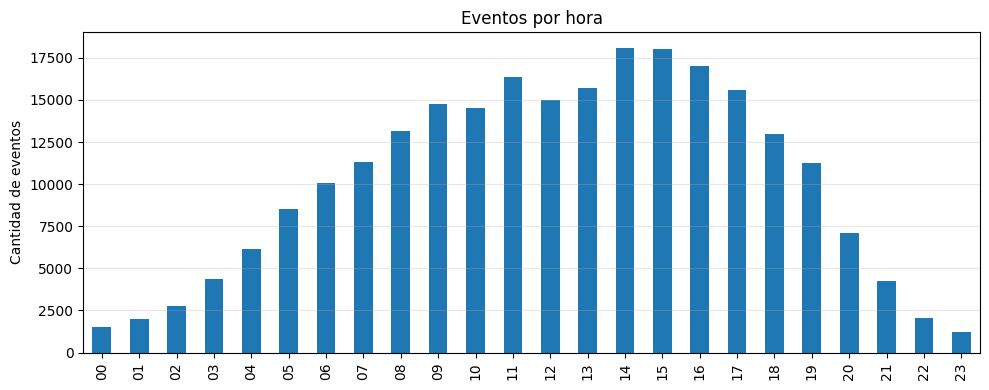

In [42]:
# Encuentra la fecha máxima y mínima
print(f"Rango: {df_log['date'].min()} - {df_log['date'].max()}")

# Eventos por día
daily_counts = df_log.groupby('date').size()

plt.figure(figsize=(10, 4))
ax = daily_counts.plot(kind='bar')
ax.set_title('Eventos por día')

ax.set_ylabel('Cantidad de eventos')
ax.set_xlabel('')
ax.grid(axis='y', alpha=0.3)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

# Eventos por hora
hour_counts = df_log['event'].dt.hour.value_counts().sort_index()

plt.figure(figsize=(10, 4))
ax = hour_counts.plot(kind='bar')
ax.set_title('Eventos por hora')
ax.set_xlabel('')
ax.set_ylabel('Cantidad de eventos')
ax.set_xticks(range(24))
ax.set_xticklabels([f'{h:02d}' for h in range(24)])
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

In [43]:
#Contar eventos por día (DAU) (dispositivos únicos)
df_daily = (df_log.dropna(subset=['date']).groupby('date', as_index=False).agg(events=('eventname','size'),dau=('device', 'nunique'))).sort_values('date').reset_index(drop=True)

# Estimar un nivel base con la mediana de los últimos 7 días
# Nivel base = mediana de los últimos 7 días observados
df_inicio = df_daily['date'].max() - pd.Timedelta(days=6)
baseline = df_daily.loc[df_daily['date'] >= df_inicio, 'events'].median()

# Umbral de detección de racha (>= 3 días coinsecutivos sobre el umbral)
umbral = 0.90 * baseline

df_ok = df_daily['events'] >= umbral

# Tomar como inicio el primer día con al menos 3 días consecutivos por arriba del umbral.
# id de rachas (True / False) y longitud de racha para True. 
gid = (df_ok != df_ok.shift()).cumsum()
df_runlen = df_ok.groupby(gid).cumsum()
df_daily['ok'] = df_ok
df_daily['run'] = df_runlen
 
# Primer día "completo" por nivel de eventos
start_date = df_daily.loc[(df_daily['ok']) & (df_daily['run'] >=1),'date'].iloc[0]

# Verificar desde cuándo existen todos los grupos del experimento
groups_per_day = df_log.groupby('date')['group'].nunique().sort_index()

# Obtener la primer fecha en donde existen los 3 grupos (A1, A2 y B)
start_all_groups = groups_per_day[groups_per_day == 3].index.min()
start_final = max(start_date, start_all_groups)
end_final = df_log['date'].max()

# Obtener el nuevo dataframe filtrado con los datos reales.
df_stable = df_log[(df_log['date'] >= start_final) & (df_log['date'] <= end_final)].copy()

print(f"Periodo de datos completos: {start_final} - {end_final}")

Periodo de datos completos: 2019-08-01 - 2019-08-07


In [44]:
print('Registros eliminados de la fuente original:', df_log.shape[0] - df_stable.shape[0])

Registros eliminados de la fuente original: 2826


In [ ]:
# Estudio del embudo de eventos
Observa qué eventos hay en los registros y sufrecuencia de suceso. Ordénalos por frecuencia.